In [2]:
from __future__ import annotations

import sys
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
DATASETS = ["drd2", "hiv", "kdr", "sol"]
TASK = "hi"

def find_project_root(start: Path | None = None) -> Path:
    """
    Walk upward until the project root is found.
    """
    if start is None:
        start = Path.cwd().resolve()

    current = start
    while current != current.parent:
        if (
            (current / "data").exists()
            and (current / "utils").exists()
            and (current / "results").exists()
        ):
            return current
        current = current.parent

    raise RuntimeError("Could not find project root containing data/, utils/, and results/.")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.fingerprints import compute_fingerprints

OUT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_ROOT / "figures"

# Root feature cache directory
FEATURE_CACHE_ROOT = PROJECT_ROOT / "features" / "classifier_shift_test" / TASK

for d in (OUT_ROOT, FIG_ROOT, FEATURE_CACHE_ROOT):
    d.mkdir(parents=True, exist_ok=True)

FINGERPRINTS = ["ecfp4", "maccs", "rdkit_desc"]

TOPK_VALUES = [10, 20, 50]

N_CV_SPLITS = 5

print(f"Datasets     : {DATASETS}")
print(f"Task         : {TASK}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Output root  : {OUT_ROOT}")
print(f"Figure root  : {FIG_ROOT}")
print(f"Feature cache: {FEATURE_CACHE_ROOT}")

Datasets     : ['drd2', 'hiv', 'kdr', 'sol']
Task         : hi
Project root : /home/f.capria/drug-discovery-lohi
Output root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi
Figure root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures
Feature cache: /home/f.capria/drug-discovery-lohi/features/classifier_shift_test/hi


In [4]:
def get_dataset_paths(dataset: str) -> dict:
    """
    Return all input/output paths for one Hi dataset.
    """
    data_dir = PROJECT_ROOT / "data" / TASK / dataset

    binding_results_dir = (
        PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / dataset
    )

    out_dir = OUT_ROOT / dataset
    fig_dir = out_dir / "figures"
    feat_dir = out_dir / "discriminator_features"
    feature_cache_dir = FEATURE_CACHE_ROOT / dataset

    for d in (out_dir, fig_dir, feat_dir, feature_cache_dir):
        d.mkdir(parents=True, exist_ok=True)

    return {
        "data_dir": data_dir,
        "binding_results_dir": binding_results_dir,
        "out_dir": out_dir,
        "fig_dir": fig_dir,
        "feat_dir": feat_dir,
        "feature_cache_dir": feature_cache_dir,
    }

In [5]:
for dataset in DATASETS:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    print(f"\nChecking {dataset}-{TASK}")
    print("Data dir:", data_dir)

    assert data_dir.exists(), f"Missing data directory: {data_dir}"

    for fname in ["test_1.csv", "test_2.csv", "test_3.csv"]:
        path = data_dir / fname
        assert path.exists(), f"Missing file: {path}"

    if not paths["binding_results_dir"].exists():
        print(f"Warning: binding results directory not found: {paths['binding_results_dir']}")
        print("Feature overlap with activity models will be skipped unless this directory exists.")
    else:
        print("Binding results directory found.")


Checking drd2-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/drd2
Binding results directory found.

Checking hiv-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/hiv
Binding results directory found.

Checking kdr-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/kdr
Binding results directory found.

Checking sol-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/sol
Binding results directory found.


## Load subsets and build pair definitions

In [6]:
SUBSET_FILES = {
    "F1": "test_3.csv",
    "F2": "test_2.csv",
    "F3": "test_1.csv",
}

PAIRS = list(combinations(["F1", "F2", "F3"], 2))


def load_subsets(dataset: str) -> dict[str, pd.DataFrame]:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    subsets = {}
    for subset_name, filename in SUBSET_FILES.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path).copy()
        df["subset"] = subset_name
        df["source_file"] = filename
        subsets[subset_name] = df

    return subsets


for dataset in DATASETS:
    subsets_tmp = load_subsets(dataset)
    print(f"\n{dataset.upper()}-{TASK}")
    for subset_name, df in subsets_tmp.items():
        print(f"  {subset_name} ({SUBSET_FILES[subset_name]}): {len(df)} molecules")
    print(f"  Pairs: {PAIRS}")


DRD2-hi
  F1 (test_3.csv): 1191 molecules
  F2 (test_2.csv): 1194 molecules
  F3 (test_1.csv): 1190 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

HIV-hi
  F1 (test_3.csv): 7848 molecules
  F2 (test_2.csv): 7848 molecules
  F3 (test_1.csv): 7847 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

KDR-hi
  F1 (test_3.csv): 2285 molecules
  F2 (test_2.csv): 3125 molecules
  F3 (test_1.csv): 3116 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

SOL-hi
  F1 (test_3.csv): 721 molecules
  F2 (test_2.csv): 721 molecules
  F3 (test_1.csv): 721 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]


## Featurization and pair dataset builder

In [6]:
def get_smiles_col(df: pd.DataFrame) -> str:
    """Return the SMILES column name."""
    for col in ["smiles", "SMILES", "canonical_smiles"]:
        if col in df.columns:
            return col
    raise ValueError(f"No SMILES column found. Available columns: {df.columns.tolist()}")


def get_feature_names(fp_type: str, n_features: int) -> list[str]:
    """Return feature names for each molecular representation."""
    if fp_type == "ecfp4":
        return [f"ecfp4_bit_{i}" for i in range(n_features)]

    if fp_type == "maccs":
        return [f"maccs_key_{i}" for i in range(n_features)]

    if fp_type == "rdkit_desc":
        try:
            from rdkit.Chem import Descriptors
            names = [name for name, _ in Descriptors._descList]
            return names[:n_features]
        except Exception:
            return [f"rdkit_desc_{i}" for i in range(n_features)]

    return [f"{fp_type}_feature_{i}" for i in range(n_features)]


def build_pair_dataset(
    dataset: str,
    subsets: dict[str, pd.DataFrame],
    fold_a: str,
    fold_b: str,
    fp_type: str,
) -> tuple[np.ndarray, np.ndarray, list[str], pd.DataFrame]:
    """
    Build one binary fold-discrimination dataset.

    Label convention:
        fold_a -> 0
        fold_b -> 1

    The activity label is not used here.
    """
    df_a = subsets[fold_a].copy()
    df_b = subsets[fold_b].copy()

    smiles_col = get_smiles_col(df_a)
    pair_name = f"{fold_a}_vs_{fold_b}"

    df_a["shift_label"] = 0
    df_b["shift_label"] = 1

    pair_df = pd.concat([df_a, df_b], ignore_index=True)
    pair_df["dataset"] = dataset
    pair_df["pair"] = pair_name
    pair_df["fold_a"] = fold_a
    pair_df["fold_b"] = fold_b

    smiles = pair_df[smiles_col].astype(str).tolist()
    y = pair_df["shift_label"].to_numpy(dtype=int)

    cache_path = (
        get_dataset_paths(dataset)["feature_cache_dir"]
        / f"{pair_name}_{fp_type}.npz"
    )

    X = compute_fingerprints(
        smiles_list=smiles,
        fp_type=fp_type,
        cache_path=cache_path,
    )

    feature_names = get_feature_names(fp_type, X.shape[1])

    return X, y, feature_names, pair_df

In [7]:
import os
import contextlib
from rdkit import RDLogger

VERBOSE = False

@contextlib.contextmanager
def silence_output():
    """
    Suppress noisy stdout/stderr and RDKit logs during featurization and fitting.
    """
    RDLogger.DisableLog("rdApp.*")
    with open(os.devnull, "w") as devnull:
        with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
            yield
    RDLogger.EnableLog("rdApp.*")

## In-sample discrimination — maximum separability

In [ ]:
def make_high_capacity_discriminators(fp_type: str) -> dict:
    """
    High-capacity / weakly-regularized fold discriminators.
    Used only for in-sample maximum separability.
    """
    scale = fp_type == "rdkit_desc"

    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )

    lr = LogisticRegression(
        C=1e4,
        penalty="l2",
        solver="lbfgs",
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    svm = LinearSVC(
        C=1e4,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    if scale:
        lr = Pipeline([
            ("scaler", StandardScaler()),
            ("model", lr),
        ])
        svm = Pipeline([
            ("scaler", StandardScaler()),
            ("model", svm),
        ])

    return {
        "DT": dt,
        "LR": lr,
        "SVM": svm,
    }


def shift_scores_from_balanced_accuracy(bal_acc: float) -> tuple[float, float]:
    """
    Convert balanced accuracy into:
    - shift_score_01 in [0, 1]
    - proxy_A_distance in [0, 2]
    """
    shift_score_01 = max(0.0, 2.0 * bal_acc - 1.0)
    proxy_a_distance = max(0.0, 4.0 * bal_acc - 2.0)
    return shift_score_01, proxy_a_distance


insample_rows = []
fitted_high_capacity = {}

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== High-capacity in-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name, model in make_high_capacity_discriminators(fp_type).items():
                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                fitted = clone(model)

                with silence_output():
                    fitted.fit(X, y)

                y_pred = fitted.predict(X)

                acc = accuracy_score(y, y_pred)
                bal_acc = balanced_accuracy_score(y, y_pred)
                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(bal_acc)

                insample_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "high_capacity_insample",
                    "accuracy": acc,
                    "balanced_accuracy": bal_acc,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                })

                fitted_high_capacity[(dataset, pair_name, fp_type, model_name)] = {
                    "model": fitted,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                }

df_insample = pd.DataFrame(insample_rows)

for dataset, sub in df_insample.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_high_capacity_insample.csv"
    )
    sub.to_csv(out_path, index=False)

df_insample.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv",
    index=False,
)

display(
    df_insample
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="balanced_accuracy",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.958  0.952
                 rdkit_desc   1.000  0.985  0.984
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.932  0.927
                 rdkit_desc   1.000  0.963  0.962
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.974  0.972
                 rdkit_desc   1.000  0.984  0.984
hiv     F1_vs_F2 ecfp4        1.000  0.789  0.790
                 maccs        1.000  0.690  0.692
                 rdkit_desc   1.000  0.699  0.698
        F1_vs_F3 ecfp4        1.000  0.775  0.776
                 maccs        1.000  0.688  0.689
                 rdkit_desc   1.000  0.706  0.707
        F2_vs_F3 ecfp4        1.000  0.825  0.825
                 maccs        0.999  0.734  0.735
                 rdkit_desc   1.000  0.747  0.748
kdr     F1_vs_F2 ecfp4        0.816  0.784  0.783
                 maccs        0.816  0.727  0.726
                 rdkit_desc   0.816  0.730  0.734
        F1_vs_F3 ecfp4        0.817  0.784  0.784
                 maccs        0.817  0.713  0.716
                 rdkit_desc   0.817  0.734  0.734
        F2_vs_F3 ecfp4        0.683  0.683  0.683
                 maccs        0.683  0.637  0.638
                 rdkit_desc   0.683  0.648  0.651
sol     F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.651  0.655
                 rdkit_desc   1.000  0.679  0.687
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        0.999  0.714  0.716
                 rdkit_desc   1.000  0.729  0.734
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.693  0.692
                 rdkit_desc   1.000  0.707  0.704

- DRD2 — tutto separabile, anche linearmente. Balanced accuracy quasi 1.0 su tutte le coppie e tutti i fingerprint, inclusi LR e SVM. Significa che i tre fold di DRD2 sono chimicamente distinti non solo in modo non-lineare (quello lo fa sempre il DT) ma anche con separatori lineari su fingerprint binari. Lo shift è reale e strutturato. Però ricorda che questo è in-sample con modelli overfittati — la domanda chiave è quanto di questa separabilità sopravvive out-of-sample con la grid search.
- HIV — pattern interessante e asimmetrico. Il DT arriva sempre a 1.0 (overfit perfetto), ma LR e SVM si fermano a 0.69-0.83. Questo ti dice che i fold di HIV non sono linearmente separabili su fingerprint singoli — ci sono molecole dei due fold che occupano lo stesso spazio di feature. La coppia F2 vs F3 è la più distinguibile (LR ECFP4 = 0.825), F1 vs F2 e F1 vs F3 sono più sovrapposte. Questo suggerisce che F1 è il fold più "centrale" chimicamente, mentre F2 e F3 sono più distinti tra loro. Interessante da confrontare con i tuoi risultati OOD.
- KDR — il caso anomalo e quello più rivelatore. È l'unico dataset dove anche il DT non raggiunge 1.0. La balanced accuracy del DT è 0.816 per F1 vs F2 e F1 vs F3, e scende a 0.683 per F2 vs F3. Questo significa che i fold di KDR sono parzialmente sovrapposti anche per un classificatore con capacità illimitata — non è solo un problema di linearità ma di vera sovrapposizione nello spazio delle feature. La coppia F2 vs F3 è la meno distinguibile. Questo è paradossale rispetto a quello che ti aspettavi: KDR è il dataset dove il protocollo OOD dà i guadagni maggiori (15-35 punti), eppure i fold sono meno separabili di DRD2 e Sol. Potrebbe significare che lo shift su KDR non è di tipo "scaffold diverso" ma qualcosa di più sottile — magari i fold condividono scaffold simili ma con pattern di attività diversi, e il modello selezionato con random shuffle sovrastima la sua capacità di generalizzare proprio perché la validazione interna è fuorviante in uno spazio chimico parzialmente sovrapposto. Questa è un'ipotesi da verificare con il confronto Lista A vs Lista B.
- Sol — DT sempre a 1.0, LR e SVM collassano su MACCS e RDKit desc. Su ECFP4 LR e SVM raggiungono 1.0 — separabilità lineare perfetta su fingerprint a 1024 bit. Su MACCS e RDKit descriptors scendono a 0.65-0.73. Questo dice che lo shift in Sol è principalmente codificato nei bit ECFP4 (sottostrutture specifiche) e molto meno nei descrittori globali. È coerente col fatto che Sol-Hi è un task su solubilità, dove il scaffold fa molta differenza ma i descriptor fisico-chimici medi possono essere simili tra fold.

Il punto più importante prima dei risultati out-of-sample. KDR sfida direttamente l'ipotesi semplice "più shift → più optimism gap". Su KDR hai il gap maggiore ma la separabilità in-sample più bassa tra tutti i dataset. Questo è potenzialmente il risultato più interessante della tesi, non un problema — significa che la relazione tra shift e optimism gap è più complessa di una semplice correlazione lineare, e i due paper di Kifer e Ben-David hanno molto da dire su perché questo accade. In particolare Ben-David ti dice che il bound sulla generalizzazione dipende sia dalla A-distance sia dalla capacità del miglior classificatore congiunto — se quel classificatore congiunto è debole (fold sovrapposti), il bound è diverso da quello che ti aspetti. Vale la pena mettere da parte questa osservazione e aspettare i dati out-of-sample prima di concludere, ma tienila in testa.

## Out-of-sample discrimination — generalizable shift + A-distance

In [9]:
from sklearn.model_selection import GridSearchCV


def allowed_fingerprints_for_model(model_name: str) -> list[str]:
    """
    Match the fingerprint availability of the main OOD-vs-random study.
    """
    if model_name == "LR":
        return ["ecfp4", "maccs", "rdkit_desc"]
    if model_name in ["DT", "SVM"]:
        return ["ecfp4", "maccs"]
    raise ValueError(f"Unknown model_name: {model_name}")


def get_main_search_grid(dataset: str, model_name: str) -> dict:
    """
    Return the same hyperparameter grid used in the main OOD-vs-random study.

    HIV uses reduced grids for computational reasons, consistently with
    the main experiments.
    """
    is_hiv = dataset == "hiv"

    if model_name == "DT":
        if is_hiv:
            return {
                "max_depth": [3, 5, 8, 10, 15],
                "min_samples_split": [10, 20, 50],
                "min_samples_leaf": [5, 10, 20, 50],
                "criterion": ["gini", "entropy"],
                "class_weight": [None, "balanced"],
                "max_features": ["sqrt", "log2"],
                "ccp_alpha": [0.0, 0.0001, 0.001],
            }

        return {
            "max_depth": [3, 5, 7, 10, 15, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "criterion": ["gini", "entropy"],
            "class_weight": [None, "balanced"],
            "max_features": ["sqrt", "log2", None],
            "ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
        }

    if model_name == "LR":
        if is_hiv:
            return {
                "C": [0.01, 0.1, 1.0, 5.0, 10.0],
                "l1_ratio": [0.0, 0.5, 1.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
            "class_weight": [None, "balanced"],
        }

    if model_name == "SVM":
        if is_hiv:
            return {
                "C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [
                0.001, 0.005, 0.01, 0.05, 0.1,
                0.25, 0.5, 1.0, 2.0, 5.0,
                10.0, 25.0, 50.0, 100.0,
            ],
            "class_weight": [None, "balanced"],
        }

    raise ValueError(f"Unknown model_name: {model_name}")


def make_main_search_discriminator(dataset: str, fp_type: str, model_name: str):
    """
    Build discriminator + grid using the same search space as the main
    protocol-comparison study.
    """
    if fp_type not in allowed_fingerprints_for_model(model_name):
        return None, None

    if model_name == "DT":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
        grid = get_main_search_grid(dataset, model_name)

    elif model_name == "LR":
        max_iter = 50000 if dataset == "hiv" else 15000

        base = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            max_iter=max_iter,
            random_state=RANDOM_STATE,
        )

        grid = get_main_search_grid(dataset, model_name)

        if fp_type == "rdkit_desc":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("model", base),
            ])
            grid = {f"model__{k}": v for k, v in grid.items()}
        else:
            estimator = base

    elif model_name == "SVM":
        estimator = LinearSVC(
            max_iter=20000,
            random_state=RANDOM_STATE,
        )
        grid = get_main_search_grid(dataset, model_name)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return estimator, grid


search_cv_rows = []
best_search_models = {}

skf = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== Same-search out-of-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name in ["DT", "LR", "SVM"]:
                estimator, param_grid = make_main_search_discriminator(
                    dataset=dataset,
                    fp_type=fp_type,
                    model_name=model_name,
                )

                if estimator is None:
                    continue

                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                search = GridSearchCV(
                    estimator=estimator,
                    param_grid=param_grid,
                    scoring={
                        "accuracy": "accuracy",
                        "balanced_accuracy": "balanced_accuracy",
                        "roc_auc": "roc_auc",
                    },
                    refit="balanced_accuracy",
                    cv=skf,
                    n_jobs=-1,
                    return_train_score=True,
                    error_score=np.nan,
                )

                with silence_output():
                    search.fit(X, y)

                best_idx = search.best_index_
                cvres = search.cv_results_

                acc_mean = float(cvres["mean_test_accuracy"][best_idx])
                acc_std = float(cvres["std_test_accuracy"][best_idx])

                bal_mean = float(cvres["mean_test_balanced_accuracy"][best_idx])
                bal_std = float(cvres["std_test_balanced_accuracy"][best_idx])

                roc_mean = float(cvres["mean_test_roc_auc"][best_idx])
                roc_std = float(cvres["std_test_roc_auc"][best_idx])

                train_bal_mean = float(cvres["mean_train_balanced_accuracy"][best_idx])
                train_bal_std = float(cvres["std_train_balanced_accuracy"][best_idx])

                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(
                    bal_mean
                )

                search_cv_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "same_search_cv",
                    "cv_accuracy_mean": acc_mean,
                    "cv_accuracy_std": acc_std,
                    "cv_balanced_accuracy_mean": bal_mean,
                    "cv_balanced_accuracy_std": bal_std,
                    "cv_roc_auc_mean": roc_mean,
                    "cv_roc_auc_std": roc_std,
                    "cv_train_balanced_accuracy_mean": train_bal_mean,
                    "cv_train_balanced_accuracy_std": train_bal_std,
                    "cv_train_test_gap_balanced_accuracy": train_bal_mean - bal_mean,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "best_params": json.dumps(search.best_params_),
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                })

                best_search_models[(dataset, pair_name, fp_type, model_name)] = {
                    "model": search.best_estimator_,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                    "best_params": search.best_params_,
                }

df_search_cv = pd.DataFrame(search_cv_rows)

for dataset, sub in df_search_cv.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_same_search_cv.csv"
    )
    sub.to_csv(out_path, index=False)

df_search_cv.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv",
    index=False,
)

display(
    df_search_cv
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="proxy_A_distance",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.836  1.951  1.951
                 maccs        1.770  1.705  1.715
                 rdkit_desc     NaN  1.799    NaN
        F1_vs_F3 ecfp4        1.763  1.864  1.866
                 maccs        1.736  1.622  1.612
                 rdkit_desc     NaN  1.691    NaN
        F2_vs_F3 ecfp4        1.814  1.928  1.933
                 maccs        1.832  1.784  1.794
                 rdkit_desc     NaN  1.802    NaN
hiv     F1_vs_F2 ecfp4        0.705  0.980  0.986
                 maccs        0.866  0.728  0.735
                 rdkit_desc     NaN  0.763    NaN
        F1_vs_F3 ecfp4        0.712  0.922  0.934
                 maccs        0.774  0.723  0.723
                 rdkit_desc     NaN  0.782    NaN
        F2_vs_F3 ecfp4        0.789  1.133  1.140
                 maccs        0.946  0.898  0.900
                 rdkit_desc     NaN  0.962    NaN
kdr     F1_vs_F2 ecfp4        0.946  0.968  0.979
                 maccs        1.016  0.864  0.877
                 rdkit_desc     NaN  0.867    NaN
        F1_vs_F3 ecfp4        1.002  0.997  1.007
                 maccs        0.966  0.817  0.831
                 rdkit_desc     NaN  0.891    NaN
        F2_vs_F3 ecfp4        0.512  0.494  0.458
                 maccs        0.493  0.472  0.461
                 rdkit_desc     NaN  0.498    NaN
sol     F1_vs_F2 ecfp4        0.340  0.497  0.497
                 maccs        0.380  0.239  0.241
                 rdkit_desc     NaN  0.358    NaN
        F1_vs_F3 ecfp4        0.549  0.763  0.752
                 maccs        0.499  0.588  0.580
                 rdkit_desc     NaN  0.602    NaN
        F2_vs_F3 ecfp4        0.629  0.757  0.763
                 maccs        0.555  0.494  0.480
                 rdkit_desc     NaN  0.505    NaN

- DRD2 — shift fortissimo e generalizzabile: A-distance tra 1.6 e 1.95 su tutte le coppie e tutti i fingerprint. È il dataset con lo shift più alto in assoluto, e lo shift è completamente generalizzabile — non sparisce out-of-sample. Tutte e tre le coppie hanno valori simili, quindi i tre fold sono tutti ugualmente distanti tra loro. Su ECFP4 LR arriva a 1.95, praticamente al massimo teorico di 2. Questo dice che DRD2 ha uno shift di scaffold netto e strutturato: i fold sono chimicamente segregati in modo che un modello lineare su bit può imparare a distinguerli perfettamente anche in cross-validation. Però — e questo è il punto da capire — il protocollo OOD su DRD2 non dà un vantaggio enorme rispetto a random shuffle (i tuoi risultati mostravano differenze piccole e miste). Shift alto ma optimism gap non drammatico. Questo è il primo segnale che la relazione shift-gap non è monotona semplice.
- HIV — shift medio e molto variabile tra coppie Qui il pattern è asimmetrico e interessante. F2 vs F3 è la coppia con shift più alto (LR ECFP4 = 1.133, quasi il doppio di F1 vs F2 = 0.980). F1 è quindi il fold più "neutro" — quando lo confronti con F2 o F3 il discriminatore fa più fatica. Ma la cosa più importante è che su MACCS e rdkit_desc i valori scendono molto (0.72-0.96) rispetto a ECFP4, il che significa che lo shift di HIV è codificato principalmente in sottostrutture circolari specifiche (ECFP4) e meno in proprietà globali. HIV è un dataset con pochissimi attivi (<1%) e chemotipi molto diversi tra fold — il shift che misuri qui è probabilmente uno shift di chemiotipo degli attivi, non della popolazione generale.
- KDR — il risultato più importante di tutto lo studio Guarda F2 vs F3: A-distance 0.512, 0.493, 0.458, 0.498. Praticamente zero su tutti i modelli e tutti i fingerprint. F2 e F3 sono indistinguibili da un discriminatore generalizzabile. Mentre F1 vs F2 e F1 vs F3 hanno A-distance attorno a 0.95-1.0, quindi F1 è il fold "anomalo" — chimicamente distante dagli altri due, che invece si somigliano. Questo spiega parzialmente perché KDR ha il gap maggiore nel tuo studio: il fold 1 ha un inner split (F1 come inner_train, F2 come inner_val) dove i due lati sono distanti (A-distance ~1.0), quindi la validazione OOD interna è genuinamente informativa. I fold 2 e 3 invece hanno inner split meno distanti. Ma c'è ancora la domanda aperta: perché KDR ha il gap maggiore se Sol ha A-distance ancora più bassa?
- Sol — shift basso, quasi nullo I valori sono tra 0.24 e 0.76, molto inferiori a DRD2 e HIV. Su MACCS i valori sono particolarmente bassi (0.24-0.59). Sol è il dataset dove i tre fold sono più chimicamente sovrapposti — molecole di solubilità diversa ma con scaffold e proprietà globali simili tra fold. Questo è coerente con il task: Sol-Hi misura la solubilità, che dipende da proprietà fisico-chimiche distribuite su tutta la molecola, non da farmacofori specifici. I fold sono costruiti su Tanimoto ECFP4, ma se ECFP4 non cattura bene le differenze rilevanti per la solubilità, i fold finiscono per essere chimicamente simili nel senso che conta.
- La tabella che ti serve per il notebook di confronto
Adesso puoi già costruire il risultato centrale. Aggrega la A-distance per dataset (media su coppie e fingerprint e modelli, oppure usa solo LR ECFP4 come riferimento pulito) e mettila contro l'optimism gap medio del tuo studio. Quello che emergerà non è una correlazione lineare semplice, e questo è scientificamente più interessante:
DatasetA-distance (LR ECFP4, media coppie)Optimism gap (OOD vs random)DRD2~1.91piccolo/mistoHIV~1.01piccolo/mistoKDR~0.81 (ma F2vsF3 ≈ 0)grandeSol~0.67piccolo
La relazione non è monotona. DRD2 ha shift altissimo ma gap piccolo. KDR ha shift medio ma gap enorme. Sol ha shift basso e gap piccolo. Questo è un risultato genuino, non un fallimento — dice che la A-distance da sola non predice il gap, e che la struttura interna dello shift (quale coppia è distante, e se quella coppia corrisponde all'inner split OOD) conta più della media. In Ben-David questo si traduce nel fatto che il bound dipende non solo da dAd_\mathcal{A}
dA​ ma anche dall'errore del miglior ipotesi congiunta — se lo spazio chimico è tale che nessun modello generalizza bene su entrambi i fold, il gap diventa inevitabile indipendentemente da quanto sia grande la A-distance.
Il confronto Lista A vs Lista B che arriva adesso è esattamente quello che ti serve per capire il meccanismo: su KDR, le feature che il discriminatore usa per separare F1 da F2/F3 sono le stesse che predicono l'attività, o sono scaffold features diverse? Se sono le stesse, stai chiedendo al modello di imparare una regola che non si trasferisce tra fold — e quello è il vero motivo del gap grande.

## List B: discriminator feature importances

In [10]:
def get_base_model(model):
    """Return final estimator if model is a Pipeline."""
    return model.steps[-1][1] if isinstance(model, Pipeline) else model


def tree_minimum_depths(tree_model, n_features: int) -> np.ndarray:
    """
    Minimum depth at which each feature appears in a fitted Decision Tree.
    Features never used receive NaN.
    """
    tree = tree_model.tree_
    min_depth = np.full(n_features, np.nan)

    stack = [(0, 0)]  # node_id, depth

    while stack:
        node_id, depth = stack.pop()
        feature_id = tree.feature[node_id]

        if feature_id >= 0:
            if np.isnan(min_depth[feature_id]) or depth < min_depth[feature_id]:
                min_depth[feature_id] = depth

            left = tree.children_left[node_id]
            right = tree.children_right[node_id]

            if left != -1:
                stack.append((left, depth + 1))
            if right != -1:
                stack.append((right, depth + 1))

    return min_depth


def extract_discriminator_importance(
    fitted_model,
    feature_names: list[str],
    model_name: str,
) -> pd.DataFrame:
    """
    Extract feature importances from a fitted fold discriminator.

    DT:
        - impurity-based feature importance
        - minimum depth

    LR/SVM:
        - coefficient
        - absolute coefficient as importance
    """
    base = get_base_model(fitted_model)
    n_features = len(feature_names)

    if model_name == "DT":
        importance = np.asarray(base.feature_importances_)
        min_depth = tree_minimum_depths(base, n_features)

        df = pd.DataFrame({
            "feature_idx": np.arange(n_features),
            "feature_name": feature_names,
            "importance": importance,
            "abs_importance": importance,
            "coefficient": np.nan,
            "direction": "tree",
            "minimum_depth": min_depth,
            "used": importance > 0,
        })

    else:
        coef = np.asarray(base.coef_).ravel()
        importance = np.abs(coef)

        df = pd.DataFrame({
            "feature_idx": np.arange(len(coef)),
            "feature_name": feature_names[:len(coef)],
            "importance": importance,
            "abs_importance": importance,
            "coefficient": coef,
            "direction": np.where(coef > 0, "towards_fold_b",
                          np.where(coef < 0, "towards_fold_a", "zero")),
            "minimum_depth": np.nan,
            "used": importance > 0,
        })

    total = df["abs_importance"].sum()
    df["normalized_importance"] = (
        df["abs_importance"] / total if total > 0 else 0.0
    )

    df = df.sort_values(
        ["abs_importance", "minimum_depth"],
        ascending=[False, True],
        na_position="last",
    ).reset_index(drop=True)

    df["rank"] = np.arange(1, len(df) + 1)

    return df


def collect_listB_from_models(model_dict: dict, source_name: str) -> pd.DataFrame:
    """
    Extract List B shift features from a fitted-model dictionary.

    Expected key:
        (dataset, pair_name, fp_type, model_name)

    Expected value:
        {
            "model": fitted estimator,
            "feature_names": list,
            ...
        }
    """
    all_rows = []

    for (dataset, pair_name, fp_type, model_name), obj in model_dict.items():
        fitted_model = obj["model"]
        feature_names = obj["feature_names"]

        df_imp = extract_discriminator_importance(
            fitted_model=fitted_model,
            feature_names=feature_names,
            model_name=model_name,
        )

        fold_a, fold_b = pair_name.split("_vs_")

        df_imp.insert(0, "source", source_name)
        df_imp.insert(0, "model", model_name)
        df_imp.insert(0, "fingerprint", fp_type)
        df_imp.insert(0, "fold_b", fold_b)
        df_imp.insert(0, "fold_a", fold_a)
        df_imp.insert(0, "pair", pair_name)
        df_imp.insert(0, "task", TASK)
        df_imp.insert(0, "dataset", dataset)

        all_rows.append(df_imp)

        top = df_imp.head(50)
        feat_dir = get_dataset_paths(dataset)["feat_dir"]
        top.to_csv(
            feat_dir / f"listB_{source_name}_{pair_name}_{fp_type}_{model_name}.csv",
            index=False,
        )

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


listB_parts = []

if "fitted_high_capacity" in globals() and fitted_high_capacity:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=fitted_high_capacity,
            source_name="high_capacity_insample",
        )
    )

if "best_search_models" in globals() and best_search_models:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=best_search_models,
            source_name="same_search_cv",
        )
    )

df_listB = pd.concat(listB_parts, ignore_index=True)

# Save dataset-specific full List B tables
for dataset, sub in df_listB.groupby("dataset"):
    sub.to_csv(
        get_dataset_paths(dataset)["out_dir"] / "listB_discriminator_feature_importance.csv",
        index=False,
    )

# Save cross-dataset full List B table
df_listB.to_csv(
    OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv",
    index=False,
)

display(
    df_listB
    .query("rank <= 10")
    .loc[:, [
        "dataset", "source", "pair", "fingerprint", "model",
        "rank", "feature_idx", "feature_name",
        "abs_importance", "coefficient", "direction", "minimum_depth"
    ]]
    .head(30)
)

,dataset,source,pair,fingerprint,model,rank,feature_idx,feature_name,abs_importance,coefficient,direction,minimum_depth
0,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,1,631,ecfp4_bit_631,0.253813,NaN,tree,0.0
1,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,2,197,ecfp4_bit_197,0.110528,NaN,tree,1.0
2,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,3,74,ecfp4_bit_74,0.071733,NaN,tree,3.0
3,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,4,456,ecfp4_bit_456,0.071702,NaN,tree,2.0
4,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,5,378,ecfp4_bit_378,0.049435,NaN,tree,3.0
5,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,6,650,ecfp4_bit_650,0.040149,NaN,tree,3.0
6,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,7,969,ecfp4_bit_969,0.034994,NaN,tree,4.0
7,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,8,486,ecfp4_bit_486,0.023098,NaN,tree,2.0
8,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,9,441,ecfp4_bit_441,0.022634,NaN,tree,5.0
9,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,10,3,ecfp4_bit_3,0.018958,NaN,tree,5.0


In [8]:
IMPORTANCE_COL_CANDIDATES = [
    "abs_importance",
    "normalized_abs_importance",
    "normalized_importance",
    "tree_importance",
    "normalized_tree_importance",
    "importance",
    "abs_weight",
    "abs_coefficient",
]

MODEL_NAME_MAP = {
    "dt": "DT",
    "decision_tree": "DT",
    "Decision Tree": "DT",
    "lr": "LR",
    "logistic_regression": "LR",
    "Logistic Regression": "LR",
    "svm": "SVM",
    "svm_linear": "SVM",
    "Linear SVM": "SVM",
}


def find_importance_col(df: pd.DataFrame) -> str:
    for col in IMPORTANCE_COL_CANDIDATES:
        if col in df.columns:
            return col
    raise ValueError(
        "No valid importance column found. "
        f"Available columns: {df.columns.tolist()}"
    )


def normalize_model_name(x) -> str:
    if pd.isna(x):
        return x
    return MODEL_NAME_MAP.get(str(x), str(x))


def load_listA_for_dataset(dataset: str) -> pd.DataFrame | None:
    """
    Load List A: activity/binding feature importances from the OOD-vs-random study.
    """
    paths = get_dataset_paths(dataset)
    path = paths["binding_results_dir"] / "feature_importance_all.csv"

    if not path.exists():
        print(f"Missing List A for {dataset}: {path}")
        return None

    df = pd.read_csv(path).copy()
    importance_col = find_importance_col(df)

    df["dataset"] = dataset
    df["source"] = "activity_model"
    df["list"] = "A_binding_activity"
    df["activity_importance"] = df[importance_col].astype(float).abs()

    if "model" in df.columns:
        df["model"] = df["model"].map(normalize_model_name)
    elif "model_short" in df.columns:
        df["model"] = df["model_short"].map(normalize_model_name)
    else:
        raise ValueError(f"No model column found in {path}")

    if "fingerprint" not in df.columns:
        if "fp_type" in df.columns:
            df["fingerprint"] = df["fp_type"]
        else:
            raise ValueError(f"No fingerprint column found in {path}")

    if "feature_idx" not in df.columns:
        raise ValueError(f"No feature_idx column found in {path}")

    if "feature_name" not in df.columns:
        df["feature_name"] = df["fingerprint"].astype(str) + "_feature_" + df["feature_idx"].astype(str)

    keep_cols = [
        "dataset", "source", "list",
        "model", "fingerprint",
        "feature_idx", "feature_name",
        "activity_importance",
    ]

    optional_cols = [
        "protocol", "fold", "rank", "direction",
        "raw_weight", "coefficient", "minimum_depth",
        "normalized_abs_importance", "tree_importance",
    ]

    keep_cols += [c for c in optional_cols if c in df.columns]

    df = df[keep_cols].copy()

    sort_cols = ["dataset", "model", "fingerprint"]
    if "protocol" in df.columns:
        sort_cols.append("protocol")
    if "fold" in df.columns:
        sort_cols.append("fold")

    df = (
        df.sort_values(sort_cols + ["activity_importance"], ascending=[True] * len(sort_cols) + [False])
        .reset_index(drop=True)
    )

    df["activity_rank"] = (
        df.groupby(sort_cols)["activity_importance"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    return df


listA_parts = []

for dataset in DATASETS:
    df_a = load_listA_for_dataset(dataset)
    if df_a is None:
        continue

    listA_parts.append(df_a)

    out_path = get_dataset_paths(dataset)["out_dir"] / "listA_activity_feature_importance.csv"
    df_a.to_csv(out_path, index=False)

df_listA = pd.concat(listA_parts, ignore_index=True) if listA_parts else pd.DataFrame()

df_listA.to_csv(
    OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv",
    index=False,
)

display(
    df_listA
    .query("activity_rank <= 10")
    .head(10)
)

,dataset,source,list,model,fingerprint,feature_idx,feature_name,activity_importance,protocol,fold,rank,direction,raw_weight,minimum_depth,normalized_abs_importance,tree_importance,activity_rank
0,drd2,activity_model,A_binding_activity,DT,ecfp4,767,ecfp4_bit_767,0.165114,OOD holdout,1,1,NaN,NaN,0.0,NaN,0.165114,1
1,drd2,activity_model,A_binding_activity,DT,ecfp4,592,ecfp4_bit_592,0.042588,OOD holdout,1,2,NaN,NaN,1.0,NaN,0.042588,2
2,drd2,activity_model,A_binding_activity,DT,ecfp4,830,ecfp4_bit_830,0.040849,OOD holdout,1,3,NaN,NaN,3.0,NaN,0.040849,3
3,drd2,activity_model,A_binding_activity,DT,ecfp4,268,ecfp4_bit_268,0.038104,OOD holdout,1,4,NaN,NaN,2.0,NaN,0.038104,4
4,drd2,activity_model,A_binding_activity,DT,ecfp4,875,ecfp4_bit_875,0.036058,OOD holdout,1,5,NaN,NaN,9.0,NaN,0.036058,5
5,drd2,activity_model,A_binding_activity,DT,ecfp4,673,ecfp4_bit_673,0.036044,OOD holdout,1,6,NaN,NaN,5.0,NaN,0.036044,6
6,drd2,activity_model,A_binding_activity,DT,ecfp4,13,ecfp4_bit_13,0.030793,OOD holdout,1,7,NaN,NaN,13.0,NaN,0.030793,7
7,drd2,activity_model,A_binding_activity,DT,ecfp4,74,ecfp4_bit_74,0.030544,OOD holdout,1,8,NaN,NaN,12.0,NaN,0.030544,8
8,drd2,activity_model,A_binding_activity,DT,ecfp4,313,ecfp4_bit_313,0.028760,OOD holdout,1,9,NaN,NaN,5.0,NaN,0.028760,9
9,drd2,activity_model,A_binding_activity,DT,ecfp4,136,ecfp4_bit_136,0.026863,OOD holdout,1,10,NaN,NaN,10.0,NaN,0.026863,10


In [11]:
# Reload saved results after kernel restart.

SHIFT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
OUT_ROOT = SHIFT_ROOT
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

search_cv_path = OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv"
insample_path = OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv"
listB_path = OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv"
listA_path = OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv"

if not search_cv_path.exists():
    raise FileNotFoundError(f"Missing file: {search_cv_path}")

df_search_cv = pd.read_csv(search_cv_path)

df_insample = pd.read_csv(insample_path) if insample_path.exists() else pd.DataFrame()
df_listB = pd.read_csv(listB_path) if listB_path.exists() else pd.DataFrame()
df_listA = pd.read_csv(listA_path) if listA_path.exists() else pd.DataFrame()

print("Loaded:")
print(f"df_search_cv : {df_search_cv.shape} from {search_cv_path}")
print(f"df_insample  : {df_insample.shape} from {insample_path if insample_path.exists() else 'missing'}")
print(f"df_listB     : {df_listB.shape} from {listB_path if listB_path.exists() else 'missing'}")
print(f"df_listA     : {df_listA.shape} from {listA_path if listA_path.exists() else 'missing'}")

Loaded:
df_search_cv : (84, 23) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_same_search_cv.csv
df_insample  : (108, 15) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_high_capacity_insample.csv
df_listB     : (96168, 18) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listB_discriminator_feature_importance.csv
df_listA     : (90960, 17) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_activity_feature_importance.csv


## Global fold-shift heatmap

C’è distribution shift tra i fold?

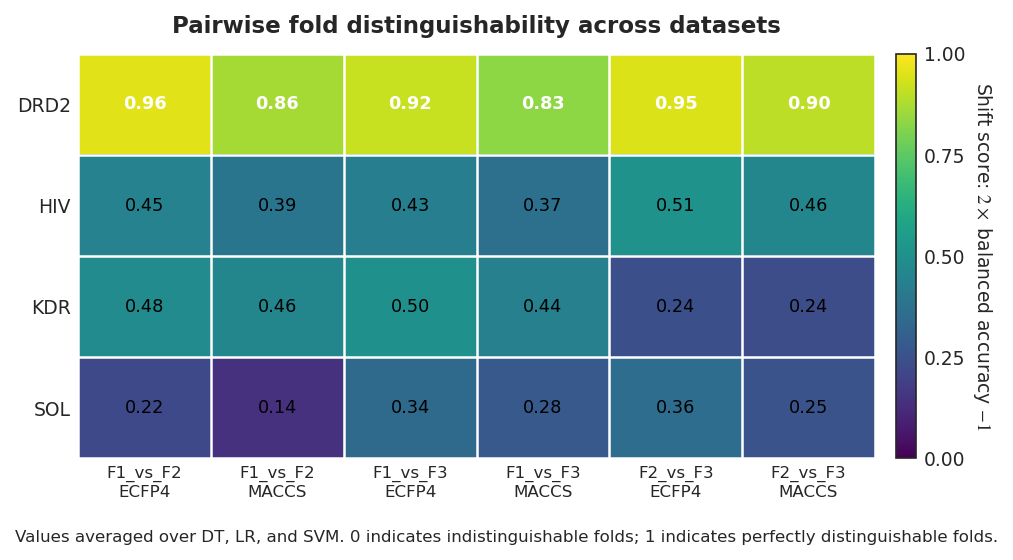

In [40]:
from textwrap import wrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global figure directory
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]

df_shift_plot = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)["shift_score_01"]
    .mean()
)

df_shift_plot["column"] = (
    df_shift_plot["pair"] + "\n" + df_shift_plot["fingerprint"].str.upper()
)

shift_mat = (
    df_shift_plot
    .pivot(index="dataset", columns="column", values="shift_score_01")
    .reindex(DATASETS)
)

# Optional: keep a stable and readable column order
ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in shift_mat.columns:
            ordered_cols.append(col)

shift_mat = shift_mat[ordered_cols]

# Paper-like matplotlib settings
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = shift_mat.shape

fig_width = max(6.8, 1.0 * n_cols)
fig_height = max(2.6, 0.55 * n_rows + 1.3)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Mask missing values, if any
data = np.ma.masked_invalid(shift_mat.values.astype(float))

cmap = mpl.colormaps["viridis"].copy()
cmap.set_bad(color="lightgray")

im = ax.imshow(
    data,
    vmin=0,
    vmax=1,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

# Short, paper-friendly title
ax.set_title(
    "Pairwise fold distinguishability across datasets",
    pad=10,
    fontweight="bold",
)

# Axis ticks and labels
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(shift_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in shift_mat.index])

# Minor grid lines between cells
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

# Remove unnecessary spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cell annotations with adaptive text color
for i in range(n_rows):
    for j in range(n_cols):
        value = shift_mat.iloc[i, j]

        if pd.notna(value):
            text_color = "white" if value >= 0.62 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_color,
                fontweight="bold" if value >= 0.80 else "normal",
            )

# Colorbar: compact and aligned
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    r"Shift score: $2 \times$ balanced accuracy $- 1$",
    rotation=270,
    labelpad=14,
)

cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(length=0)

# Optional explanatory note, smaller than title
fig.text(
    0.5,
    -0.02,
    "Values averaged over DT, LR, and SVM. "
    "0 indicates indistinguishable folds; 1 indicates perfectly distinguishable folds.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.tight_layout()

# Save both raster and vector versions
fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.pdf",
    bbox_inches="tight",
)

plt.show()

## Feature overlap heatmap, List A vs List B

Lo shift coinvolge le stesse feature del modello di attività?

In [24]:
PLOT_FPS = ["ecfp4", "maccs"]
OVERLAP_K = 20
LISTB_SOURCE = "same_search_cv"


def top_features_from_listA(
    df_a: pd.DataFrame,
    dataset: str,
    model: str,
    fingerprint: str,
    k: int,
) -> set:
    """
    Top-k activity/binding features for one dataset-model-fingerprint.
    If List A contains multiple folds/protocols, aggregate by mean activity importance.
    """
    sub = df_a[
        (df_a["dataset"] == dataset)
        & (df_a["model"] == model)
        & (df_a["fingerprint"] == fingerprint)
    ].copy()

    if sub.empty:
        return set()

    agg = (
        sub.groupby("feature_idx", as_index=False)["activity_importance"]
        .mean()
        .sort_values("activity_importance", ascending=False)
    )

    return set(agg.head(k)["feature_idx"].astype(int))


def top_features_from_listB(
    df_b: pd.DataFrame,
    dataset: str,
    pair: str,
    model: str,
    fingerprint: str,
    source: str,
    k: int,
) -> set:
    """
    Top-k shift/discriminator features for one dataset-pair-model-fingerprint.
    """
    sub = df_b[
        (df_b["dataset"] == dataset)
        & (df_b["pair"] == pair)
        & (df_b["model"] == model)
        & (df_b["fingerprint"] == fingerprint)
        & (df_b["source"] == source)
    ].copy()

    if sub.empty:
        return set()

    sub = sub.sort_values("rank", ascending=True)

    return set(sub.head(k)["feature_idx"].astype(int))


overlap_rows = []

for dataset in DATASETS:
    for pair in PAIRS:
        pair_name = f"{pair[0]}_vs_{pair[1]}"

        for fp in PLOT_FPS:
            for model in ["DT", "LR", "SVM"]:
                a_features = top_features_from_listA(
                    df_a=df_listA,
                    dataset=dataset,
                    model=model,
                    fingerprint=fp,
                    k=OVERLAP_K,
                )

                b_features = top_features_from_listB(
                    df_b=df_listB,
                    dataset=dataset,
                    pair=pair_name,
                    model=model,
                    fingerprint=fp,
                    source=LISTB_SOURCE,
                    k=OVERLAP_K,
                )

                if not a_features or not b_features:
                    continue

                overlap = len(a_features & b_features) / OVERLAP_K

                overlap_rows.append({
                    "dataset": dataset,
                    "pair": pair_name,
                    "fingerprint": fp,
                    "model": model,
                    "k": OVERLAP_K,
                    "overlap": overlap,
                    "n_overlap": len(a_features & b_features),
                })

df_overlap = pd.DataFrame(overlap_rows)

df_overlap.to_csv(
    OUT_ROOT / f"cross_dataset_listA_listB_overlap_top{OVERLAP_K}.csv",
    index=False,
)

display(df_overlap.head())

,dataset,pair,fingerprint,model,k,overlap,n_overlap
0,drd2,F1_vs_F2,ecfp4,DT,20,0.05,1
1,drd2,F1_vs_F2,ecfp4,LR,20,0.00,0
2,drd2,F1_vs_F2,maccs,DT,20,0.30,6
3,drd2,F1_vs_F2,maccs,LR,20,0.35,7
4,drd2,F1_vs_F3,ecfp4,DT,20,0.05,1


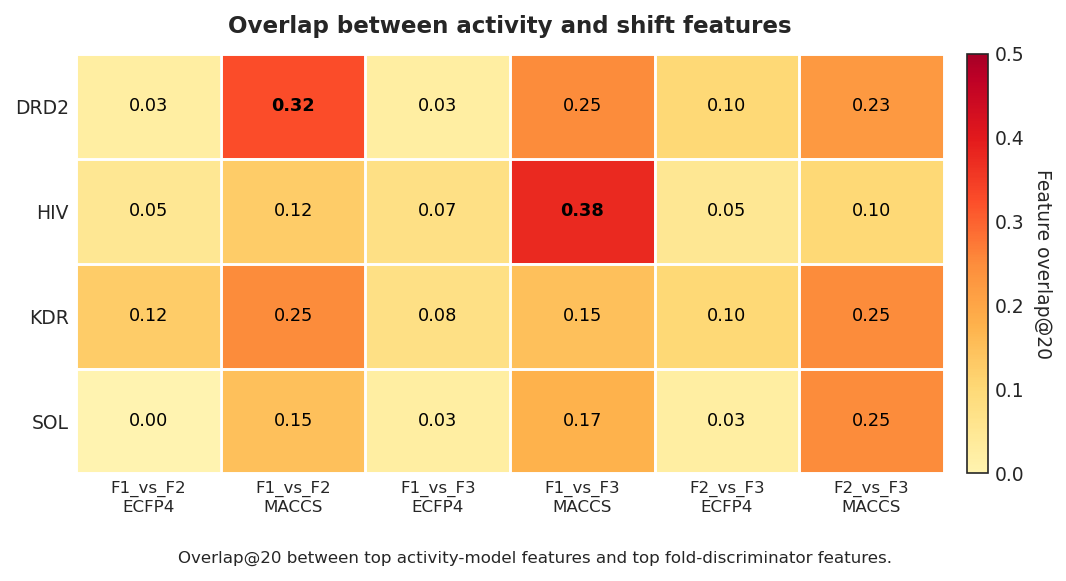

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

df_overlap_plot = (
    df_overlap
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
    .mean()
)

df_overlap_plot["column"] = (
    df_overlap_plot["pair"] + "\n" + df_overlap_plot["fingerprint"].str.upper()
)

overlap_mat = (
    df_overlap_plot
    .pivot(index="dataset", columns="column", values="overlap")
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in overlap_mat.columns:
            ordered_cols.append(col)

overlap_mat = overlap_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = overlap_mat.shape

fig, ax = plt.subplots(figsize=(7.2, 3.6))

data = np.ma.masked_invalid(overlap_mat.values.astype(float))

# Colormap chiara: niente nero
base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.08, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

vmax = 0.50

im = ax.imshow(
    data,
    vmin=0,
    vmax=vmax,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Overlap between activity and shift features",
    pad=10,
    fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(overlap_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in overlap_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = overlap_mat.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="black",
                fontweight="bold" if value >= 0.30 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    f"Feature overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=13,
)

cbar.set_ticks(np.linspace(0, vmax, 6))
cbar.ax.tick_params(length=0)

fig.text(
    0.5,
    -0.03,
    f"Overlap@{OVERLAP_K} between top activity-model features and top fold-discriminator features.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.pdf",
    bbox_inches="tight",
)

plt.show()

## Fold shift vs OOD-vs-random validation gap

questo shift spiega il gap tra random shuffle validation e OOD holdout validation?

In [31]:
OOD_ROOT = PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}


def load_protocol_per_fold_for_dataset(dataset: str) -> pd.DataFrame:
    path = OOD_ROOT / dataset / "protocol_per_fold.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing protocol_per_fold.csv for {dataset}: {path}")

    df = pd.read_csv(path).copy()
    df["dataset"] = dataset
    return df


protocol_parts = []

for dataset in DATASETS:
    try:
        protocol_parts.append(load_protocol_per_fold_for_dataset(dataset))
    except FileNotFoundError as e:
        print(e)

df_protocol_per_fold = pd.concat(protocol_parts, ignore_index=True)

print("protocol_per_fold columns:")
print(df_protocol_per_fold.columns.tolist())

display(df_protocol_per_fold.head())

protocol_per_fold columns:
['model', 'model_short', 'fingerprint', 'protocol', 'result_dir', 'fold', 'inner_pr_auc', 'inner_train_pr_auc', 'train_pr_auc', 'test_pr_auc', 'inner_test_gap', 'train_test_gap', 'best_params', 'inner_split_strategy', 'time_seconds', 'model_order', 'fingerprint_order', 'protocol_order', 'dataset']


,model,model_short,fingerprint,protocol,result_dir,fold,inner_pr_auc,inner_train_pr_auc,train_pr_auc,test_pr_auc,inner_test_gap,train_test_gap,best_params,inner_split_strategy,time_seconds,model_order,fingerprint_order,protocol_order,dataset
0,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,1,0.855177,0.917171,0.9080,0.6979,0.157277,0.2101,"{'ccp_alpha': 0.001, 'class_weight': None, 'cr...",holdout,9.5,0,0,0,drd2
1,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,2,0.699841,0.873181,0.8189,0.7698,-0.069959,0.0491,"{'ccp_alpha': 0.001, 'class_weight': None, 'cr...",holdout,6.2,0,0,0,drd2
2,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,3,0.737516,0.905641,0.8232,0.6815,0.056016,0.1417,"{'ccp_alpha': 0.0001, 'class_weight': None, 'c...",holdout,6.3,0,0,0,drd2
3,Decision Tree,DT,ECFP4,Random shuffle,dt_drd2_hi_random_shuffle_ecfp4,1,0.911535,0.960189,0.9522,0.6237,0.287835,0.3285,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',...",random_shuffle,13.3,0,0,1,drd2
4,Decision Tree,DT,ECFP4,Random shuffle,dt_drd2_hi_random_shuffle_ecfp4,2,0.844398,0.904329,0.8757,0.7540,0.090398,0.1217,"{'ccp_alpha': 0.0001, 'class_weight': None, 'c...",random_shuffle,10.6,0,0,1,drd2


In [32]:
def infer_fold_column(df: pd.DataFrame) -> str:
    candidates = ["fold", "outer_fold", "fold_id", "test_fold"]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        "Could not infer fold column. "
        f"Available columns: {df.columns.tolist()}"
    )


def infer_gap_column(df: pd.DataFrame) -> str:
    """
    Preferred gap:
        random inner validation score - OOD inner validation score

    Positive value means random validation is more optimistic than OOD validation.
    """
    candidates = [
        "delta_inner",
        "random_minus_ood_inner",
        "random_vs_ood_inner_gap",
        "validation_gap",
        "optimism_gap",
        "delta_val_score",
        "delta_validation_score",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        "Could not infer gap column. "
        f"Available columns: {df.columns.tolist()}"
    )

In [34]:
# ============================================================
# Pairwise shift vs OOD-random validation gap
# Build the gap from protocol_per_fold.csv
# ============================================================

PLOT_FPS = ["ecfp4", "maccs"]

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

# ----------------------------
# Shift table
# ----------------------------

df_shift_pair = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair"], as_index=False)
    ["shift_score_01"]
    .mean()
)

# ----------------------------
# Protocol gap table
# ----------------------------

df_gap_raw = df_protocol_per_fold.copy()

# Check protocol names
print("Available protocols:", sorted(df_gap_raw["protocol"].dropna().unique()))

# Normalize protocol names just in case
df_gap_raw["protocol_norm"] = df_gap_raw["protocol"].astype(str).str.lower()

def protocol_family(x: str) -> str:
    if "random" in x:
        return "random"
    if "ood" in x or "holdout" in x:
        return "ood"
    return x

df_gap_raw["protocol_family"] = df_gap_raw["protocol_norm"].map(protocol_family)

# Keep only random and OOD protocols
df_gap_raw = df_gap_raw[df_gap_raw["protocol_family"].isin(["random", "ood"])].copy()

# Fold-pair mapping
df_gap_raw["outer_fold"] = df_gap_raw["fold"].astype(int)
df_gap_raw["pair"] = df_gap_raw["outer_fold"].map(OUTER_FOLD_TO_PAIR)

# Average across models/fingerprints within each dataset-fold-protocol
df_gap_agg = (
    df_gap_raw
    .groupby(["dataset", "pair", "protocol_family"], as_index=False)
    ["inner_pr_auc"]
    .mean()
)

# Pivot random vs OOD
df_gap_pivot = (
    df_gap_agg
    .pivot_table(
        index=["dataset", "pair"],
        columns="protocol_family",
        values="inner_pr_auc",
    )
    .reset_index()
)

# Build gap: random validation - OOD validation
df_gap_pivot["ood_vs_random_gap"] = df_gap_pivot["random"] - df_gap_pivot["ood"]

df_gap_pair = df_gap_pivot[
    ["dataset", "pair", "random", "ood", "ood_vs_random_gap"]
].copy()

# ----------------------------
# Merge shift and gap
# ----------------------------

df_shift_gap = df_shift_pair.merge(
    df_gap_pair,
    on=["dataset", "pair"],
    how="inner",
)

df_shift_gap.to_csv(
    OUT_ROOT / "cross_dataset_pairwise_shift_vs_ood_random_gap.csv",
    index=False,
)

display(df_shift_gap)

Available protocols: ['OOD holdout', 'Random shuffle']


,dataset,pair,shift_score_01,random,ood,ood_vs_random_gap
0,drd2,F1_vs_F2,0.910693,0.909605,0.839768,0.069836
1,drd2,F1_vs_F3,0.871901,0.854821,0.700549,0.154272
2,drd2,F2_vs_F3,0.923641,0.900063,0.718074,0.181989
3,hiv,F1_vs_F2,0.416749,0.336133,0.111982,0.224150
4,hiv,F1_vs_F3,0.399128,0.382166,0.160568,0.221597
5,hiv,F2_vs_F3,0.483853,0.424744,0.160631,0.264113
6,kdr,F1_vs_F2,0.470839,0.982839,0.863415,0.119424
7,kdr,F1_vs_F3,0.468441,0.392862,0.779817,-0.386954
8,kdr,F2_vs_F3,0.240817,0.969813,0.849310,0.120503
9,sol,F1_vs_F2,0.182810,0.534342,0.473607,0.060735


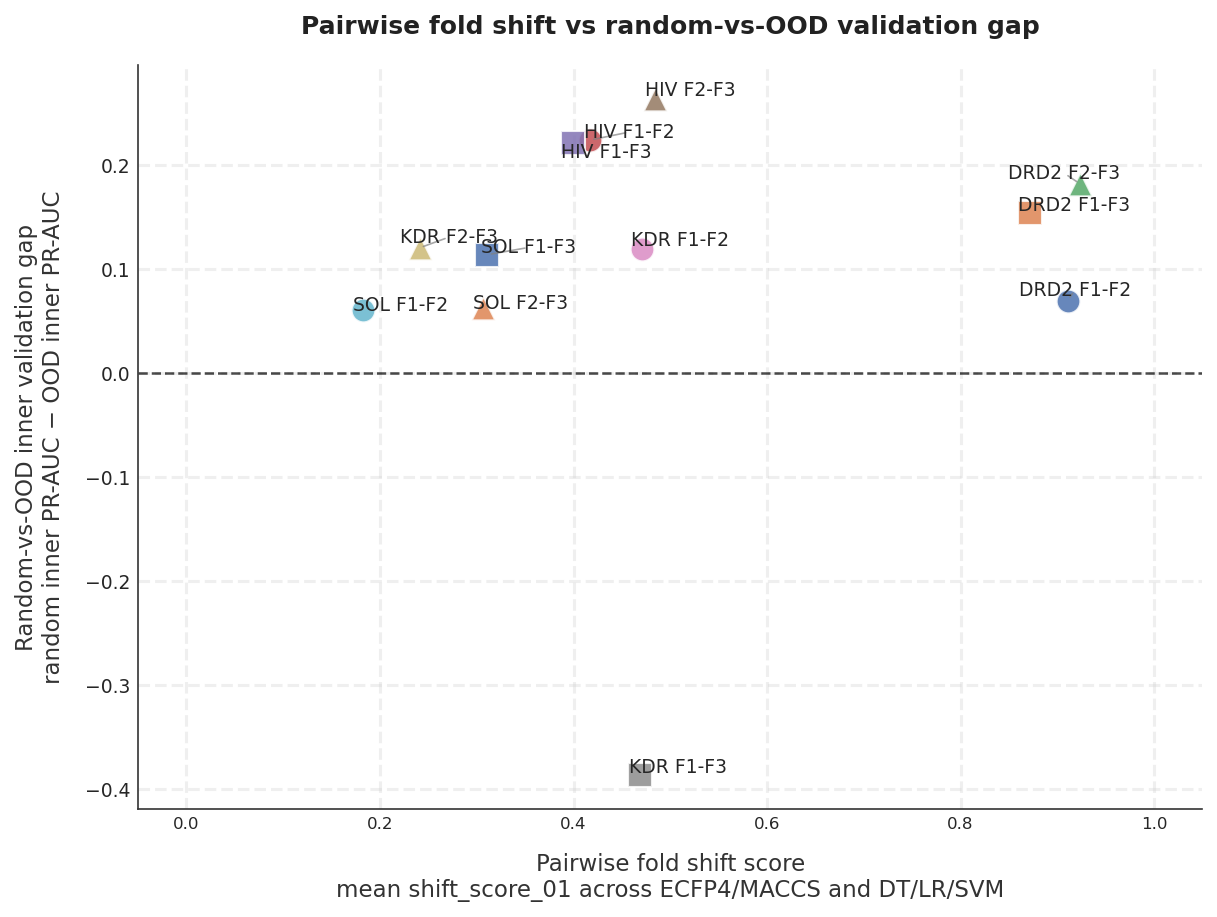

In [42]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.size': 10, 
    'axes.labelsize': 11, 
    'axes.titlesize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

markers = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

texts = []

for _, row in df_shift_gap.iterrows():
    ax.scatter(
        row["shift_score_01"],
        row["ood_vs_random_gap"],
        s=130,
        marker=markers.get(row["pair"], "o"),
        alpha=0.85,
        edgecolors="white",
        linewidth=1,
        zorder=3
    )

    txt = ax.text(
        row["shift_score_01"],
        row["ood_vs_random_gap"],
        f"{row['dataset'].upper()} {row['pair'].replace('_vs_', '-')}",
        fontsize=9,
        zorder=4
    )
    texts.append(txt)

adjust_text(
    texts,
    ax=ax,
    expand_points=(1.5, 1.5),
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8, alpha=0.7)
)

ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2, alpha=0.7, zorder=2)

ax.grid(True, linestyle="--", alpha=0.3, zorder=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("#333333")
ax.spines["left"].set_color("#333333")

ax.set_xlabel(
    "Pairwise fold shift score\n"
    "mean shift_score_01 across ECFP4/MACCS and DT/LR/SVM",
    labelpad=10,
    color="#333333"
)
ax.set_ylabel(
    "Random-vs-OOD inner validation gap\n"
    "random inner PR-AUC − OOD inner PR-AUC",
    labelpad=10,
    color="#333333"
)
ax.set_title(
    "Pairwise fold shift vs random-vs-OOD validation gap", 
    pad=15, 
    fontweight="bold",
    color="#222222"
)

ax.set_xlim(-0.05, 1.05)

fig.savefig(
    FIG_ROOT / "global_pairwise_shift_vs_ood_random_gap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()